# CAB-NB tutorial with the microbiomeMarker Kostic CRC count data

This Jupyter notebook shows a CAB-NB differential abundance workflow using the Kostic CRC count data distributed by `microbiomeMarker`.


## Prerequisites

Run this notebook with an R Jupyter kernel, typically provided by the `IRkernel` R package. Required R packages are `microbiomeMarker`, `phyloseq`, `ggplot2`, and `knitr`.  If you are running directly from this repository, the notebook loads CAB-NB with `pkgload::load_all()`.


In [1]:
library(phyloseq)
library(ggplot2)
library(knitr)

Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'knitr' was built under R version 4.4.3"


In [2]:
devtools::load_all(".")

ℹ Loading CABNB


## Load the Kostic CRC data

This follows the count-table extraction pattern. At the end of this cell, `count_mat` is taxa by samples.

In [3]:
library(microbiomeMarker)

data(kostic_crc)
ps <- kostic_crc

count_mat <- as(otu_table(ps), "matrix")
if (!taxa_are_rows(ps)) {
  count_mat <- t(count_mat)
}

metadata <- data.frame(sample_data(ps), check.names = FALSE)
tax <- data.frame(tax_table(ps), check.names = FALSE)

dim(count_mat)
table(metadata$DIAGNOSIS)


Warning message:
"package 'microbiomeMarker' was built under R version 4.4.2"
Registered S3 method overwritten by 'gplots':
  method         from     
  reorder.factor DescTools


Attaching package: 'microbiomeMarker'


The following object is masked from 'package:phyloseq':

    plot_heatmap




[1] 2505  177


Healthy   Tumor 
     91      86 

In [4]:
head(data.frame(
  samples = nsamples(ps),
  taxa = ntaxa(ps),
  taxa_are_rows = taxa_are_rows(ps),
  diagnosis_levels = paste(names(table(metadata$DIAGNOSIS)), collapse = ", "),
  zero_fraction = mean(count_mat == 0),
  min_depth = min(colSums(count_mat)),
  median_depth = median(colSums(count_mat)),
  max_depth = max(colSums(count_mat))
))

,samples,taxa,taxa_are_rows,diagnosis_levels,zero_fraction,min_depth,median_depth,max_depth
,<int>,<int>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,177,2505,TRUE,"Healthy, Tumor",0.921567,524,4722,11187


## Prepare CAB-NB inputs

The helper below selects a two-level diagnosis contrast.

In [5]:
diagnosis_levels <- c(reference="Healthy", case="Tumor")

In [6]:
counts <- t(count_mat)
if (any(abs(counts - round(counts)) > 1e-8, na.rm = TRUE)) {
  warning("The OTU table is not exactly integer-valued; rounding to nearest integer.")
}
counts <- round(counts)
storage.mode(counts) <- "integer"

common_samples <- intersect(rownames(metadata), rownames(counts))
metadata <- metadata[common_samples, , drop = FALSE]
counts <- counts[common_samples, , drop = FALSE]

keep_samples <- !is.na(metadata$DIAGNOSIS) &
  metadata$DIAGNOSIS %in% unname(diagnosis_levels) &
  rowSums(counts) > 0

metadata <- metadata[keep_samples, , drop = FALSE]
counts <- counts[keep_samples, , drop = FALSE]
metadata$diagnosis <- factor(
  as.character(metadata$DIAGNOSIS),
  levels = unname(diagnosis_levels)
)
metadata$diagnosis <- stats::relevel(metadata$diagnosis, ref = diagnosis_levels[["reference"]])
counts <- counts[rownames(metadata), , drop = FALSE]


In [7]:
design <- model.matrix(~ diagnosis, data = data.frame(metadata))

In [8]:
coef_name <- setdiff(colnames(design), "(Intercept)")[1]
coef_name

[1] "diagnosisTumor"

## Filter taxa


In [9]:
min_prevalence <- 0.10
min_total_count <- 50
min_mean_count <- 0

In [10]:

taxa_prevalence <- colMeans(counts > 0)
taxa_total <- colSums(counts)
taxa_mean <- colMeans(counts)
taxa_variance <- apply(counts, 2, var)
keep_taxa <- taxa_prevalence >= min_prevalence &
  taxa_total >= min_total_count &
  taxa_mean >= min_mean_count &
  is.finite(taxa_variance) &
  taxa_variance > 0
keep_taxa[is.na(keep_taxa)] <- FALSE

selected_taxa <- names(keep_taxa)[keep_taxa]
prior_filter <- data.frame(
  taxon = colnames(counts),
  keep = keep_taxa,
  prevalence = taxa_prevalence,
  total_count = taxa_total,
  mean_count = taxa_mean,
  variance = taxa_variance,
  stringsAsFactors = FALSE
)

counts_fit <- counts[, selected_taxa, drop = FALSE]

data.frame(
  samples = nrow(counts_fit),
  taxa_before_filter = ncol(counts),
  taxa_after_filter = ncol(counts_fit),
  min_prevalence = min_prevalence,
  min_total_count = min_total_count,
  min_mean_count = min_mean_count,
  diagnosis_reference = diagnosis_levels[["reference"]],
  diagnosis_case = diagnosis_levels[["case"]],
  coefficient = coef_name,
  zero_fraction = mean(counts_fit == 0),
  min_depth = min(rowSums(counts_fit)),
  median_depth = median(rowSums(counts_fit)),
  max_depth = max(rowSums(counts_fit))
)


samples,taxa_before_filter,taxa_after_filter,min_prevalence,min_total_count,min_mean_count,diagnosis_reference,diagnosis_case,coefficient,zero_fraction,min_depth,median_depth,max_depth
<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
177,2505,441,0.1,50,0,Healthy,Tumor,diagnosisTumor,0.6684859,494,4294,10260


In [11]:
diagnosis_summary <- data.frame(
  diagnosis = names(table(metadata$diagnosis)),
  n = as.integer(table(metadata$diagnosis)),
  median_library_size = as.numeric(tapply(rowSums(counts), metadata$diagnosis, median))
)

kable(diagnosis_summary, digits = 1)



|diagnosis |  n| median_library_size|
|:---------|--:|-------------------:|
|Healthy   | 91|                5503|
|Tumor     | 86|                3871|

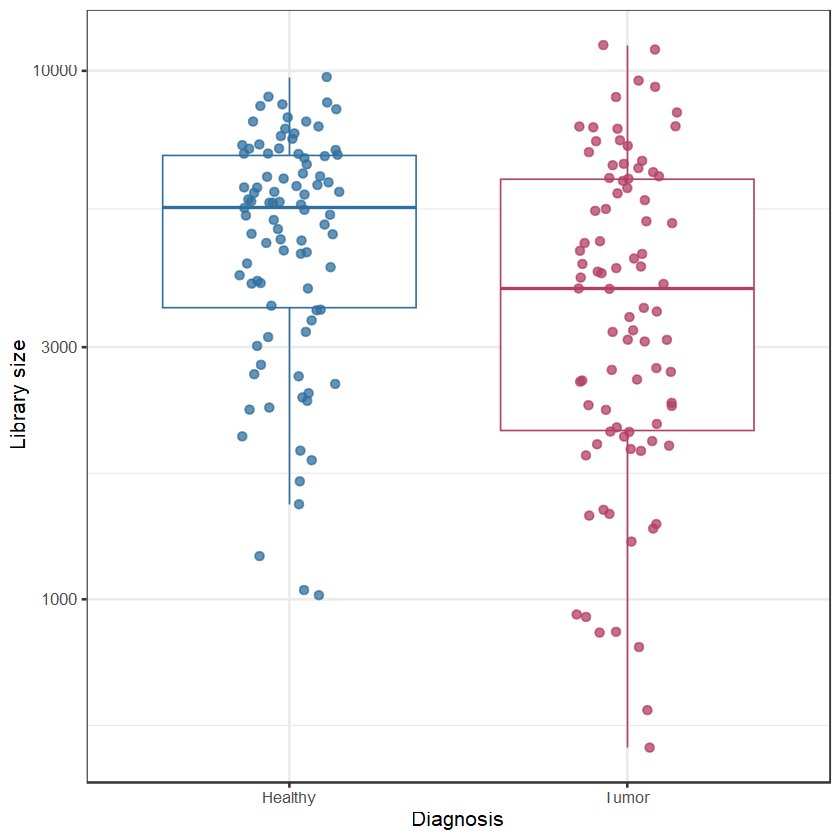

In [12]:
depth_df <- data.frame(
  sample = rownames(metadata),
  diagnosis = metadata$diagnosis,
  library_size = rowSums(counts)
)

ggplot(depth_df, aes(x = diagnosis, y = library_size, color = diagnosis)) +
  geom_boxplot(outlier.shape = NA, linewidth = 0.35) +
  geom_jitter(width = 0.15, alpha = 0.75, size = 1.8) +
  scale_y_log10() +
  scale_color_manual(values = c("#2f6f9f", "#b33f62")) +
  labs(x = "Diagnosis", y = "Library size") +
  theme_bw(base_size = 12) +
  theme(legend.position = "none")

## Fit CAB-NB

In [16]:
## Run main function using the prepared data

fit <- cabnb_fit(
  counts = counts_fit,
  metadata = data.frame(metadata),
  formula = ~ diagnosis,
  coef = coef_name,
  empirical_null = TRUE,
  zero_model = TRUE,
  glm_maxit = 25
)

fit


CABNB fit
  coefficient: diagnosisTumor 
  fitted taxa: 441 of 441 
  abundance discoveries at q <= 0.05 : 11 
  prevalence discoveries at q <= 0.05 : 0 
  information-eligible taxa: 286 
  information-filtered Any discoveries at calibrated cutoff 0.2 : 9 

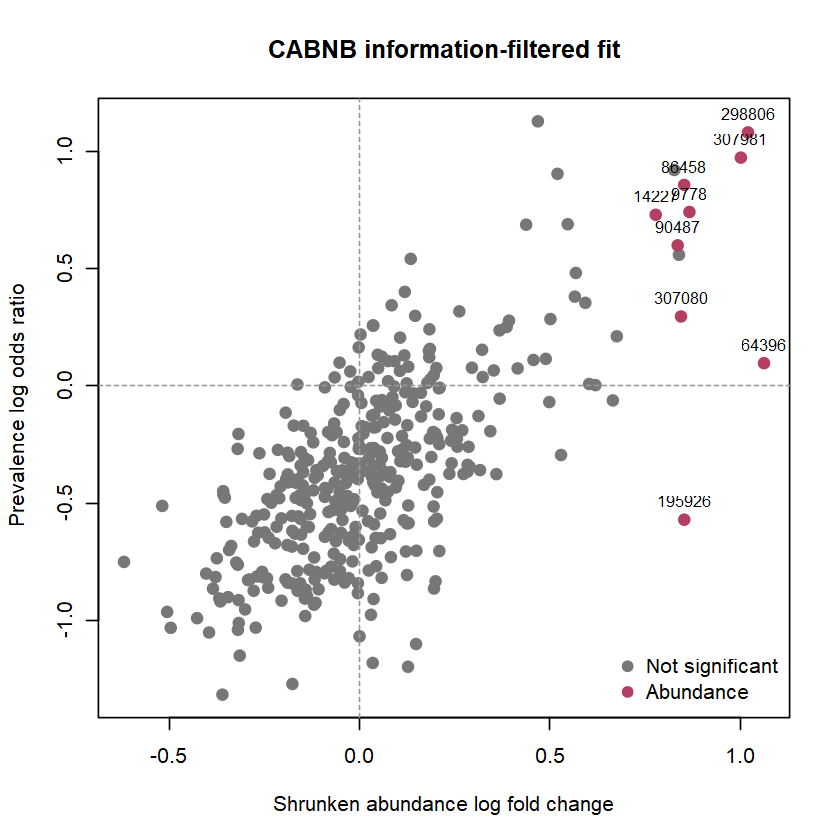

In [17]:
plot(fit, lfc="shrunken", label=TRUE)

## Annotate taxa and inspect results

In [18]:
make_taxon_label <- function(taxonomy) {
  taxonomy <- as.data.frame(taxonomy)
  rank_order <- intersect(
    c("Species", "Genus", "Family", "Order", "Class", "Phylum", "Kingdom"),
    colnames(taxonomy)
  )

  labels <- rownames(taxonomy)
  for (i in seq_len(nrow(taxonomy))) {
    values <- as.character(unlist(taxonomy[i, rank_order, drop = TRUE], use.names = FALSE))
    values <- values[!is.na(values) & nzchar(values) &
                       !values %in% c("NA", "Unknown", "unknown", "uncultured")]
    if (length(values)) {
      labels[i] <- values[1]
    }
  }
  labels
}

tax$taxon <- rownames(tax)
tax$taxon_label <- make_taxon_label(tax)

results <- fit$results
results <- merge(
  results,
  tax[, c("taxon", "taxon_label"), drop = FALSE],
  by = "taxon",
  all.x = TRUE,
  sort = FALSE
)
results <- results[match(fit$results$taxon, results$taxon), , drop = FALSE]


In [31]:
converged_results <- results[results$converged,]
top_results <- converged_results[order(converged_results$qvalue, -abs(converged_results$shrunken_log2FC)), ]
top_results <- top_results[!is.na(top_results$information_qvalue), ]
top_results <- top_results[top_results$information_qvalue<0.2, ]
top_results <- top_results[, c(
  "taxon",
  "taxon_label",
  "prevalence",
  "mean_count",
  "log2FC",
  "shrunken_log2FC",
  "pvalue",
  "qvalue",
  "prevalence_logOR",
  "prevalence_qvalue",
  "signal_type",
  "information_qvalue",
  "information_eligible"
)]

kable(head(top_results), digits = 3)



|    |taxon  |taxon_label        | prevalence| mean_count| log2FC| shrunken_log2FC| pvalue| qvalue| prevalence_logOR| prevalence_qvalue|signal_type | information_qvalue|information_eligible |
|:---|:------|:------------------|----------:|----------:|------:|---------------:|------:|------:|----------------:|-----------------:|:-----------|------------------:|:--------------------|
|353 |64396  |Fusobacterium      |      0.819|    167.407|  2.751|           1.532|      0|  0.002|            0.096|             1.000|abundance   |              0.003|TRUE                 |
|441 |298806 |Collinsella        |      0.203|      0.520|  2.778|           1.472|      0|  0.002|            1.080|             0.340|abundance   |              0.003|TRUE                 |
|331 |307981 |Klebsiella         |      0.469|      3.480|  3.275|           1.444|      0|  0.002|            0.972|             0.294|abundance   |              0.003|TRUE                 |
|266 |195926 |Bacteroidales      |    

In [32]:
kable(data.frame(
  abundance_q_0.05 = sum(is.finite(results$qvalue) & results$qvalue <= 0.05),
  prevalence_q_0.05 = sum(is.finite(results$prevalence_qvalue) & results$prevalence_qvalue <= 0.05),
  any_signal_q_0.05 = sum(results$signal_type != "none", na.rm = TRUE),
  information_fitered = sum(results$information_eligible & results$information_qvalue < 0.2)

))



| abundance_q_0.05| prevalence_q_0.05| any_signal_q_0.05| information_fitered|
|----------------:|-----------------:|-----------------:|-------------------:|
|               11|                 0|                11|                   9|

## Estimated sampling-fraction bias

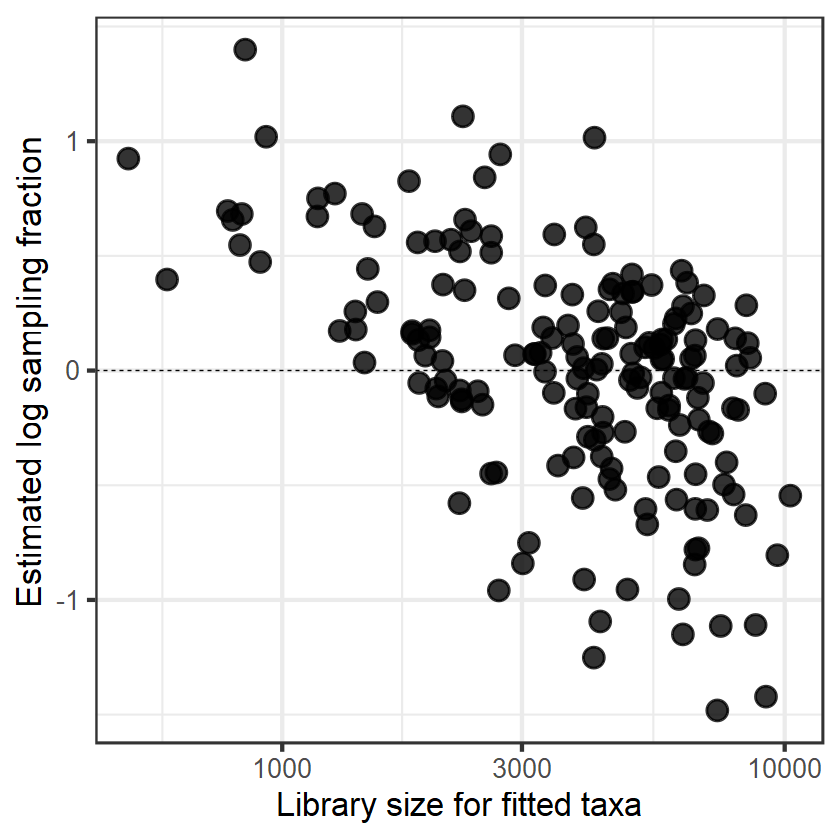

In [33]:
bias_df <- fit$sample_bias

ggplot(bias_df, aes(x = library_size, y = log_sampling_fraction)) +
  geom_point(size = 5, alpha = 0.8) +
  geom_hline(yintercept = 0, linetype = 2, linewidth = 0.3) +
  scale_x_log10() +
  scale_color_manual(values = c("#2f6f9f", "#b33f62")) +
  labs(
    x = "Library size for fitted taxa",
    y = "Estimated log sampling fraction"
  ) +
  theme_bw(base_size = 20)

## Top taxa relative abundance by diagnosis

### Abundance volcano plot


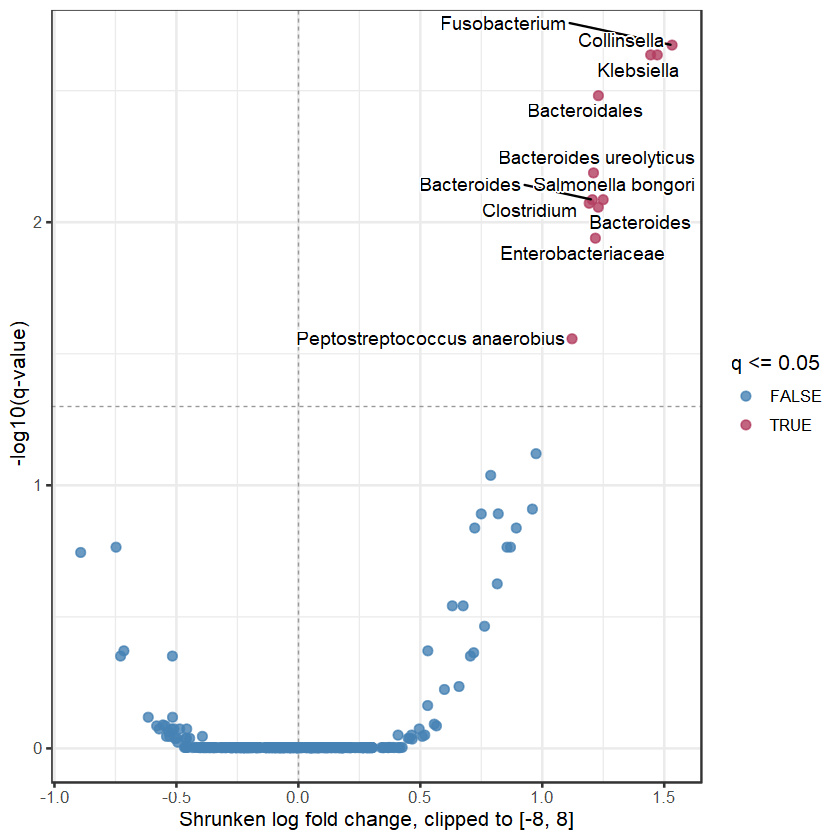

In [35]:
library(ggrepel)
plot_df <- subset(results, kept & is.finite(shrunken_log2FC) & is.finite(qvalue))
plot_df$display_log2FC <- pmax(pmin(plot_df$shrunken_log2FC, 8), -8)
plot_df$abundance_hit <- plot_df$qvalue <= 0.05

abundance_volcano <- ggplot(plot_df, aes(x = display_log2FC, y = -log10(qvalue))) +
  geom_hline(yintercept = -log10(0.05), linetype = 2, linewidth = 0.3, color = "#999999") +
  geom_vline(xintercept = 0, linetype = 2, linewidth = 0.3, color = "#999999") +
  geom_point(aes(color = abundance_hit), alpha = 0.8, size = 2) +
  geom_text_repel(aes(label=taxon_label), data=plot_df[plot_df$qvalue<0.05,], bg.colour="white")+
  scale_color_manual(values = c(`FALSE` = "steelblue", `TRUE` = "#b33f62")) +
  labs(
    x = "Shrunken log fold change, clipped to [-8, 8]",
    y = "-log10(q-value)",
    color = "q <= 0.05"
  ) +
  theme_bw(base_size = 12)
abundance_volcano

## Session information

In [ ]:
sessionInfo()